In [1]:
# ==========================================
# Lesson 26 - Simplified Aqua-OC
# ==========================================

import ee
import geemap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

ee.Initialize(project="oc-flux")

Map = geemap.Map()

point = ee.Geometry.Point([77.2090,28.6139])

collection = (
    ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
    .filterBounds(point)
    .filterDate("2023-01-01","2023-12-31")
)

image = collection.median()

Map.centerObject(point,10)

Map

Map(center=[28.613900000000005, 77.209], controls=(WidgetControl(options=['position', 'transparent_bg'], posit…

In [ ]:
Complete Aqua-OC Workflow
Satellite Image

↓

Cloud Mask

↓

Water Mask

↓

Feature Engineering

↓

Training Data

↓

Random Forest

↓

Prediction

↓

Evaluation

↓

POC Map

In [ ]:
Create Features

Our simplified model will use four Landsat bands.
These are our raw features.

In [2]:
blue = image.select("SR_B2")

green = image.select("SR_B3")

red = image.select("SR_B4")

nir = image.select("SR_B5")

In [ ]:
Create NDWI

In [3]:
ndwi = image.normalizedDifference(
    ["SR_B3","SR_B5"]
).rename("NDWI")

In [ ]:
Create MNDWI

In [4]:
mndwi = image.normalizedDifference(
    ["SR_B3","SR_B6"]
).rename("MNDWI")

In [ ]:
Build Feature Stack

In [5]:
feature_stack = ee.Image.cat([
    blue,
    green,
    red,
    nir,
    ndwi,
    mndwi
])

print(
    feature_stack.bandNames().getInfo()
)

['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'NDWI', 'MNDWI']


In [ ]:
Visualize NDWI
Observe:

Brown = land
Blue = water

In [6]:
Map.addLayer(
    ndwi,
    {
        "min":-1,
        "max":1,
        "palette":["brown","white","blue"]
    },
    "NDWI"
)

Map

Map(bottom=109612.0, center=[28.613900000000005, 77.209], controls=(WidgetControl(options=['position', 'transp…

In [ ]:
Sample Training Dataset

Since we don't yet have field-measured POC data, we'll create a small synthetic dataset.
Each row represents one field sampling location.

In [7]:
X = np.array([

[0.09,0.11,0.08,0.03,0.55,0.62],

[0.11,0.13,0.09,0.04,0.52,0.60],

[0.15,0.18,0.12,0.06,0.44,0.49],

[0.20,0.24,0.16,0.08,0.39,0.42],

[0.24,0.29,0.20,0.10,0.32,0.36],

[0.28,0.34,0.25,0.13,0.27,0.30],

[0.31,0.36,0.28,0.15,0.22,0.25],

[0.35,0.39,0.31,0.17,0.18,0.21]

])

In [ ]:
Target Values
These represent measured POC values (mg/L).

In [8]:
y = np.array([

2.1,

2.8,

3.6,

4.5,

5.4,

6.2,

7.3,

8.1

])

In [ ]:
Train-Test Split

In [9]:
X_train,\
X_test,\
y_train,\
y_test = train_test_split(

X,
y,

test_size=0.25,

random_state=42

)

In [ ]:
Train Random Forest

In [10]:
model = RandomForestRegressor(

n_estimators=200,

random_state=42

)

model.fit(

X_train,

y_train

)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [ ]:
Prediction

In [11]:
prediction = model.predict(
    X_test
)

print(prediction)

[2.675  6.8725]


In [ ]:
Evaluate

In [12]:
print("R²")

print(
    r2_score(
        y_test,
        prediction
    )
)

print()

print("MAE")

print(
    mean_absolute_error(
        y_test,
        prediction
    )
)

print()

print("RMSE")

print(
    np.sqrt(
        mean_squared_error(
            y_test,
            prediction
        )
    )
)

R²
0.9190516868512155

MAE
0.3987499999999866

RMSE
0.4836740896512724


In [ ]:
Feature Importance
In this synthetic example, NDWI and MNDWI are the most influential features.

In [13]:
feature_names = [

"Blue",

"Green",

"Red",

"NIR",

"NDWI",

"MNDWI"

]

importance = model.feature_importances_

for name,value in zip(
    feature_names,
    importance
):

    print(
        f"{name}: {value:.3f}"
    )

Blue: 0.165
Green: 0.140
Red: 0.153
NIR: 0.157
NDWI: 0.195
MNDWI: 0.191


In [ ]:
Plot Feature Importance

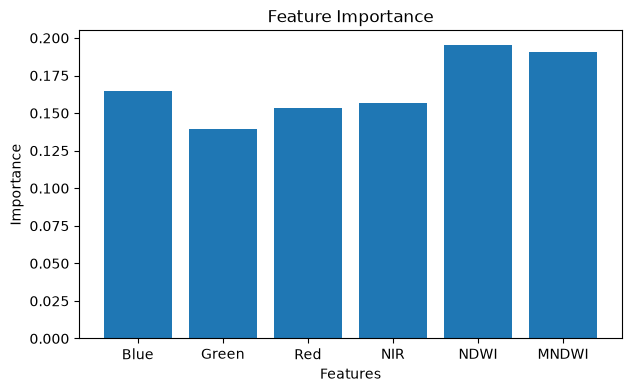

In [14]:
plt.figure(figsize=(7,4))

plt.bar(
    feature_names,
    importance
)

plt.title(
    "Feature Importance"
)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

In [ ]:
Compare Predictions

In [15]:
comparison = pd.DataFrame({

"Observed":y_test,

"Predicted":prediction

})

comparison

,Observed,Predicted
0,2.8,2.6750
1,6.2,6.8725


In [ ]:
Scatter Plot
Points closer to the red dashed line indicate better predictions.

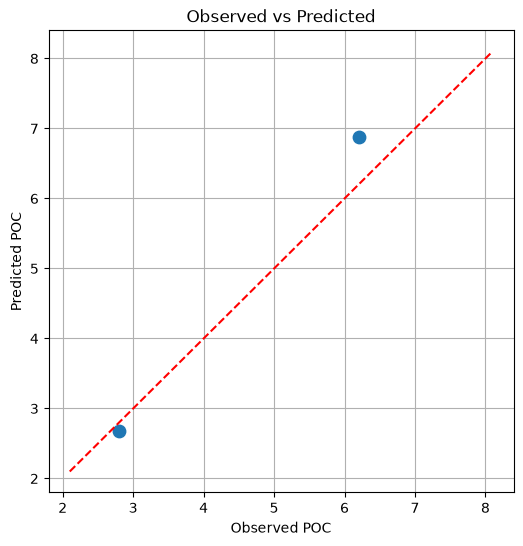

In [16]:
plt.figure(figsize=(6,6))

plt.scatter(

y_test,

prediction,

s=80

)

plt.plot(

[y.min(),y.max()],

[y.min(),y.max()],

'r--'

)

plt.xlabel("Observed POC")

plt.ylabel("Predicted POC")

plt.title("Observed vs Predicted")

plt.grid(True)

plt.show()

In [ ]:
Complete Workflow
Landsat Image
       │
       ▼
Blue
Green
Red
NIR
       │
       ▼
NDWI
MNDWI
       │
       ▼
Feature Stack
       │
       ▼
Training Dataset
       │
       ▼
Random Forest
       │
       ▼
Prediction
       │
       ▼
R²
MAE
RMSE
This is the same sequence followed by Aqua-OC, but with a simplified dataset.